In [1]:
import torch
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
kaggle_results_path = "/home/brend/projects/kaggle_runs/full_ind_vs_trans/"
kernel_types = ["2layer", "3layer", "conv1d", "conv2d", "dense_latency", "dense_resource", "exemplar", "rule4ml"]
models = {}
training_histories = {}

for kernel_type in kernel_types:
    models[kernel_type] = torch.load(f"{kaggle_results_path}/models/trans_vs_ind_test_{kernel_type}_model.pt")
    with open(f"{kaggle_results_path}/training_histories_{kernel_type}.json", "r") as f:
        training_histories[kernel_type] = json.load(f)


In [3]:
for k, v in training_histories["2layer"].items():
    print(k)

train_loss
val_loss
r_per_target
std_ratio_per_target
best_val_preds
best_val_targets
y_means
y_stds
best_val_loss
best_epoch
test_loss
test_preds
test_targets


2layer test MAPE: 1920559.0672811249
3layer test MAPE: 2607586.565531438
conv1d test MAPE: 14872084.991221972
conv2d test MAPE: inf
dense_latency test MAPE: 131061373.9239449
dense_resource test MAPE: 74969886.84699906
exemplar test MAPE: 5370012.988600354
rule4ml test MAPE: 19059662.765241902


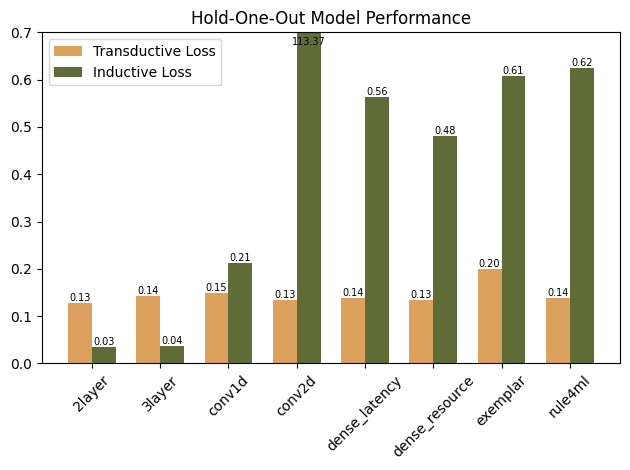

In [7]:
from ll_hls4ml.training.targets import to_luts

# Bar chart of best validation loss vs test loss for each kernel type
x = np.arange(len(kernel_types))
width = 0.35
max_height = 0.7

# Get MAPE error
for kernel_type in kernel_types:
    y_means, y_stds = torch.tensor(training_histories[kernel_type]["y_means"]), np.array(training_histories[kernel_type]["y_stds"])
    lut_preds = to_luts(torch.tensor(training_histories[kernel_type]["test_preds"]), y_means, y_stds)
    lut_targets = to_luts(torch.tensor(training_histories[kernel_type]["test_targets"]), y_means, y_stds)
    mape_error = torch.mean(torch.abs((lut_preds - lut_targets) / lut_targets))
    print(f"{kernel_type} test MAPE: {mape_error}")

fig, ax = plt.subplots()

bars1 = ax.bar(
    x - width/2,
    [training_histories[k]["best_val_loss"] for k in kernel_types],
    width,
    label="Transductive Loss",
    color="#dda15e"
)

bars2 = ax.bar(
    x + width/2,
    [training_histories[k]["test_loss"] for k in kernel_types],
    width,
    label="Inductive Loss",
    color="#606c38"
)

def label_bars(bars):
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width()/2,
            min(h, max_height - 0.03),
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=0
        )

label_bars(bars1)
label_bars(bars2)

ax.set_xticks(x)
ax.set_xticklabels(kernel_types, rotation=45)
ax.set_ylim(0, max_height)
ax.legend()
ax.set_title("Hold-One-Out Model Performance")

plt.tight_layout()
plt.show()


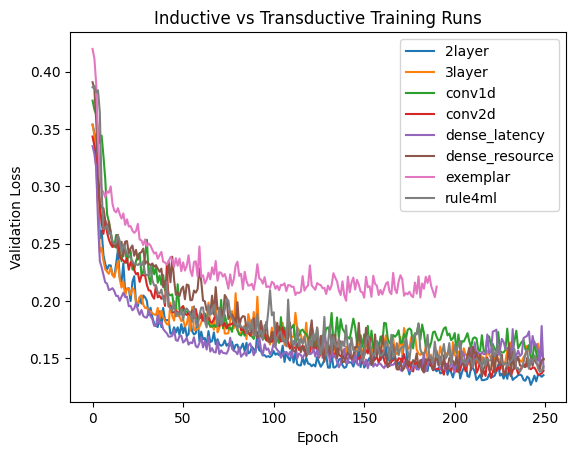

In [99]:
# Plot validation losses for each kernel type on same graph
for kernel_type in kernel_types:
    plt.plot(training_histories[kernel_type]["val_loss"], label=kernel_type)
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Inductive vs Transductive Training Runs")
plt.legend()
plt.show()

In [58]:
print(training_histories["3layer"]["best_val_preds"])

[[-1.0557547807693481, -1.0481834411621094, -0.31068724393844604, -0.8412504196166992, -0.1800839751958847, -0.682656466960907, -0.5446428656578064], [-0.061533257365226746, -0.4481605887413025, -1.2233407497406006, -0.5356580018997192, -0.17099067568778992, -0.7987693548202515, -0.806471049785614], [-0.07594461739063263, -0.03813779354095459, 0.35960620641708374, -0.42551007866859436, -0.17968182265758514, -0.35379934310913086, -0.2770644426345825], [-0.6928279995918274, -0.8509450554847717, 0.2149743288755417, -0.15326395630836487, -0.1607864499092102, -0.6316993832588196, -0.7161350250244141], [0.7278043031692505, 0.6672210693359375, 0.5769320130348206, -0.30396074056625366, -0.15394890308380127, -0.14051638543605804, -0.11102232336997986], [0.6957589983940125, 0.604377269744873, 0.47232872247695923, -0.36346960067749023, -0.15966194868087769, -0.20635129511356354, -0.16471345722675323], [0.1470714509487152, -0.21805328130722046, -0.5045588612556458, 0.3320870101451874, -0.181346625

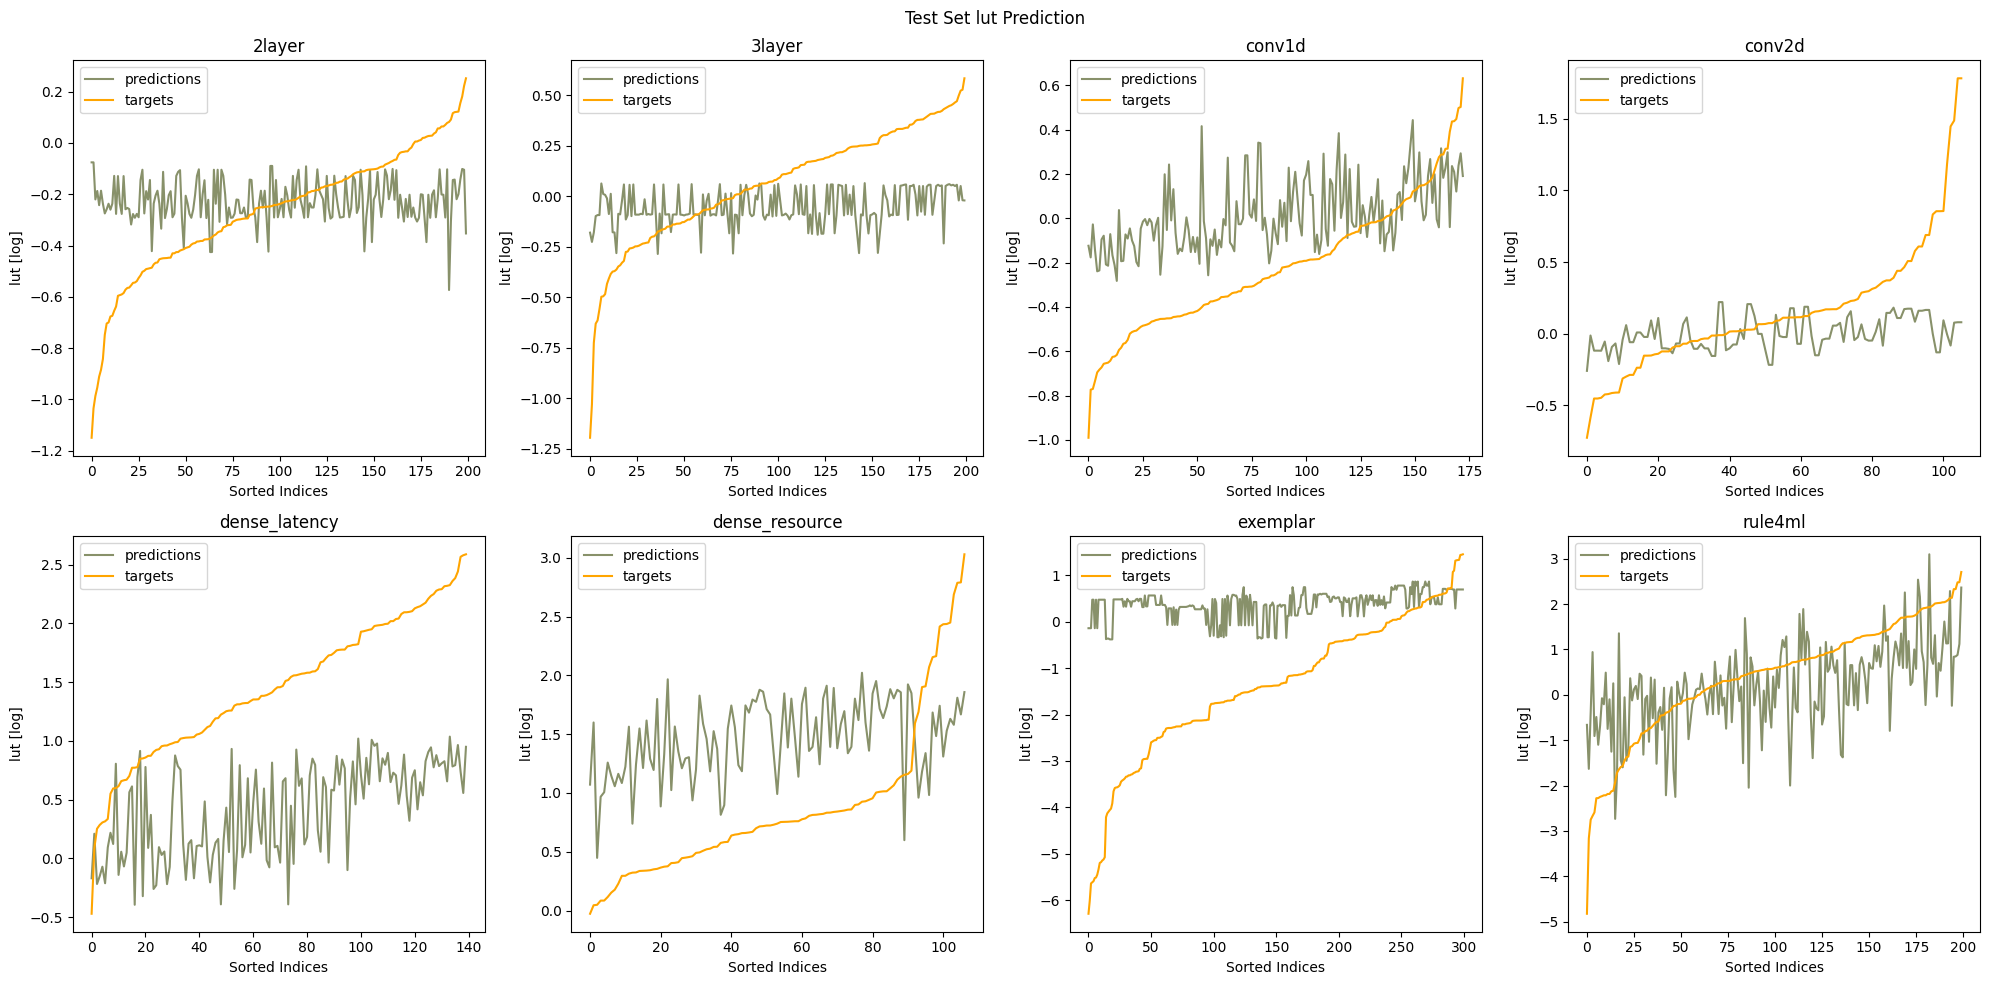

In [112]:
from ll_hls4ml.io.schema import LABEL_KEYS
label = "lut"
lbl_idx = LABEL_KEYS.index(label)

# Plot validation preds vs targets for each kernel type on multi-figure
num_kernels = len(kernel_types)
num_rows = 2
num_cols = num_kernels // num_rows
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5))

for i, kernel_type in enumerate(kernel_types):
    preds = np.array(training_histories[kernel_type]["test_preds"])[:, lbl_idx]
    targets = np.array(training_histories[kernel_type]["test_targets"])[:, lbl_idx]
    sorted_idx = targets.argsort()
    ax = axes[i // num_cols, i % num_cols]
    ax.plot(preds[sorted_idx], label="predictions", color="#606c38", alpha=0.75)
    ax.plot(targets[sorted_idx], label="targets", color="orange")
    ax.set_xlabel("Sorted Indices")
    ax.set_ylabel(f"{label} [log]")
    ax.set_title(f"{kernel_type}")
    ax.legend()
fig.suptitle(f"Test Set {label} Prediction")
plt.tight_layout()
plt.show()

(177, 6)


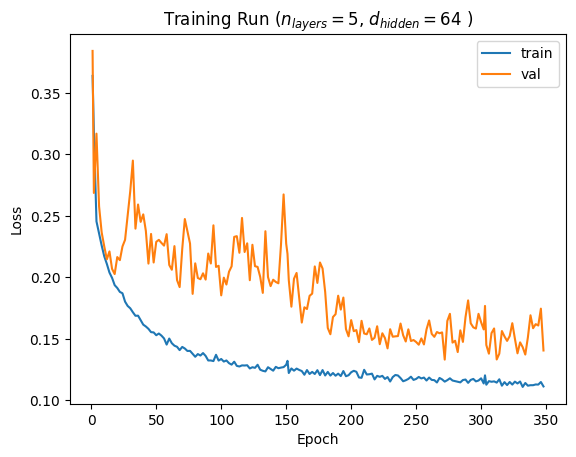

In [28]:
import re
import numpy as np
import matplotlib.pyplot as plt

f1 = "../../kaggle_runs/8/ll-hls4ml-distributed-fit.log"
f2 = "../../kaggle_runs/9/ll-hls4ml-distributed-fit (1).log"
f3 = "../../kaggle_runs/10/ll-hls4ml-distributed-fit (1).log"
with open(f1) as f:
    text = f.read()

pattern = re.compile(
    r"Epoch\s+(\d+)/(\d+)\s+train=([\d.]+)\s+val=([\d.]+)\s+R=([\d.]+)\s+std_r=([\d.]+)"
)

data = np.array([
    [
        int(epoch),
        int(total_epochs),
        float(train),
        float(val),
        float(r),
        float(std_r),
    ]
    for epoch, total_epochs, train, val, r, std_r in pattern.findall(text)
])
last_epoch = data[-1, 0]

with open(f2) as f:
    text = f.read()

data = np.append(data, 
    [[
        last_epoch + int(epoch),
        int(total_epochs),
        float(train),
        float(val),
        float(r),
        float(std_r),
     ]
    for epoch, total_epochs, train, val, r, std_r in pattern.findall(text)
    ],
    axis=0)
last_epoch = data[-1, 0]

with open(f3) as f:
    text = f.read()

data = np.append(data, 
    [[
        last_epoch + int(epoch),
        int(total_epochs),
        float(train),
        float(val),
        float(r),
        float(std_r),
     ]
    for epoch, total_epochs, train, val, r, std_r in pattern.findall(text)
    ],
    axis=0)

print(data.shape)

plt.plot(data[:, 0], data[:, 2], label="train")
plt.plot(data[:, 0], data[:, 3], label="val")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(rf"Training Run ($n_{{layers}}=5$, $d_{{hidden}}=64$ )")
plt.legend()
plt.show()

In [30]:
from json import load
from pathlib import Path
import torch
from torch import nn

from ll_hls4ml.data.dataset import HeteroGraphDataset
from ll_hls4ml.data.splits import random_train_val_split
from ll_hls4ml.data.vocab import load_vocab
from ll_hls4ml.models.registry import build
from ll_hls4ml.training import make_loader
from ll_hls4ml.training.distributed import cleanup_ddp, is_main_process, setup_from_env
from ll_hls4ml.training.loops import _json_converter, fit, _persist_on_cpu, validate_one_epoch, _broadcast_target_stats

device = torch.device("cuda")
tensor_dir = Path("../../data/tensors/")
vocab, max_pos, _ = load_vocab(tensor_dir / "vocab.json")
vocab_sizes = {k: len(v) for k, v in vocab.items()}

# max_per_kernel_type =  {
#     "2layer":         200,
#     "3layer":         300,
#     "conv1d":         300,
#     "conv2d":         300,
#     "dense_latency":  300,
#     "dense_resource": 300,
#     "exemplar":       300,
#     "rule4ml":        300,
#   }

val_frac = 0.2
test_frac = 0.1
ds = HeteroGraphDataset(tensor_dir, types=None, max_per_type=None, silent=False)
train_val_ds, test_ds = random_train_val_split(ds, val_fraction=test_frac, seed=42)
train_ds, val_ds = random_train_val_split(train_val_ds, val_fraction=val_frac, seed=42)

batch_size = 2
train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = make_loader(test_ds, batch_size=batch_size, shuffle=False)

model = build(
    "rgcn",
    node_vocab_sizes=vocab_sizes,
    edge_pos_vocab_size=max_pos,
    hidden_dim=64,
    num_layers=5,
    dropout=0.3,
).to(device)

load_model_path = Path("../../kaggle_runs/9/artifacts/models/trans_vs_ind_test_model.pt")
if load_model_path:
    state_dict = torch.load(load_model_path)
    model.load_state_dict(state_dict)
    print(f"Loading {load_model_path}")
model.eval()


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.HuberLoss(reduction="mean", delta=1.0)
y_means, y_stds = _broadcast_target_stats(train_loader.dataset, device, distributed=False)


# print("Evaluating on train set...")
# train_loss, train_preds, train_targets, _, _ = validate_one_epoch(
#     model, train_loader, criterion, device, y_means, y_stds
# )
# print(train_loss)

# print("Evaluating on val set...")
# val_loss, val_preds, val_targets, _, _ = validate_one_epoch(
#     model, val_loader, criterion, device, y_means, y_stds
# )
# print(val_loss)

print("Evaluating on test set...")
test_loss, test_preds, test_targets, _, _ = validate_one_epoch(
    model, test_loader, criterion, device, y_means, y_stds
)
print(test_loss)


Indexed 1426 graphs across 9 type(s)
  2layer: 200
    avg size: 0.66 MB
    total size: 132.08 MB
  3layer: 200
    avg size: 0.72 MB
    total size: 144.95 MB
  conv1d: 173
    avg size: 5.33 MB
    total size: 922.18 MB
  conv2d: 106
    avg size: 5.44 MB
    total size: 576.12 MB
  dense_latency: 140
    avg size: 3.36 MB
    total size: 471.00 MB
  dense_resource: 107
    avg size: 3.45 MB
    total size: 368.93 MB
  exemplar: 300
    avg size: 1.51 MB
    total size: 452.00 MB
  rule4ml: 200
    avg size: 2.06 MB
    total size: 412.56 MB


/home/brend/projects/ll-hls4ml/src/ll_hls4ml/models/rgcn.py:45: UserWarning: There exist node types ({'constant'}) whose representations do not get updated during message passing as they do not occur as destination type in any edge type. This may lead to unexpected behavior.
  self.conv = HeteroConv(


Loading ../../kaggle_runs/9/artifacts/models/trans_vs_ind_test_model.pt
Evaluating on test set...
0.09965527532491046


4


/tmp/ipykernel_14020/1828575664.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  preds = np.array(test_preds_luts.cpu() + 1)[:, i]
/tmp/ipykernel_14020/1828575664.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(test_targets_luts.cpu() + 1)[:, i]


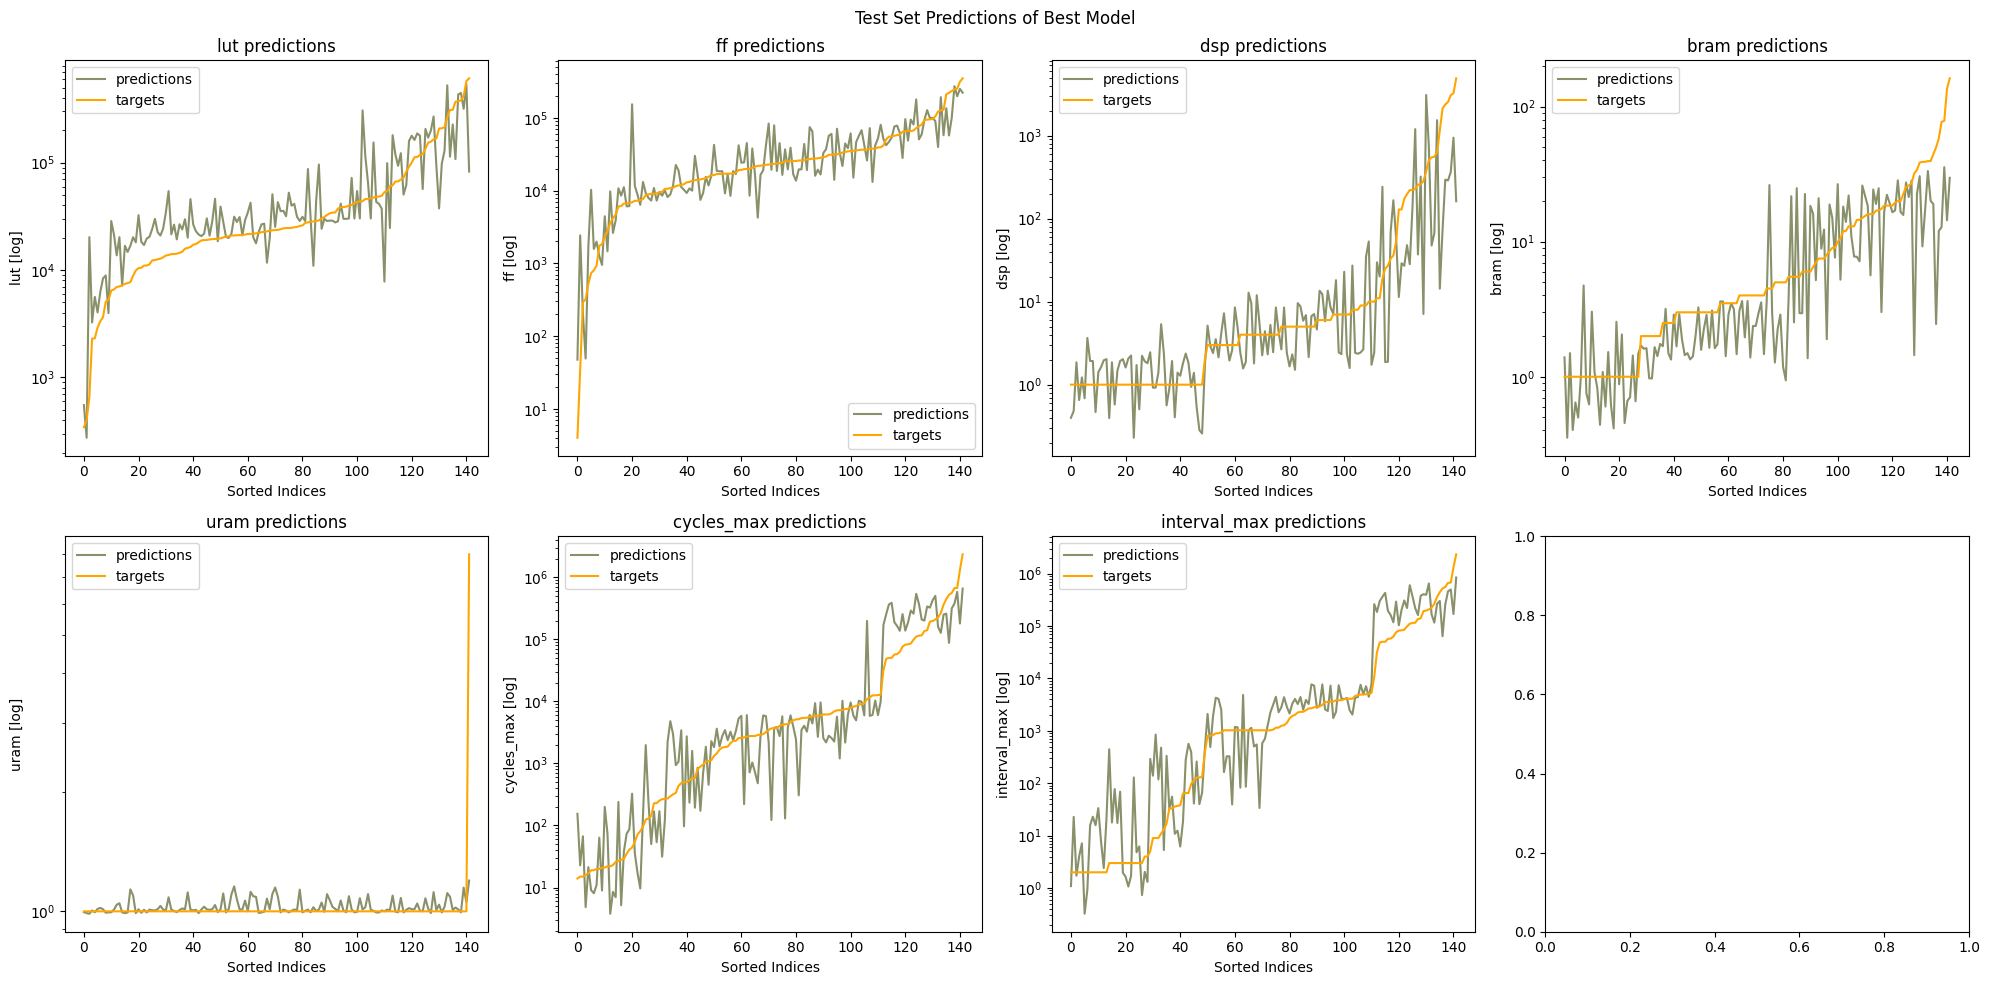

In [ ]:
from ll_hls4ml.io.schema import LABEL_KEYS
from ll_hls4ml.training.targets import to_luts
import math

# Plot validation preds vs targets for each kernel type on multi-figure
num_kernels = len(LABEL_KEYS)
num_rows = 2
num_cols = math.ceil(len(LABEL_KEYS) / num_rows)
print(num_cols)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 5))

test_preds_luts = to_luts(torch.tensor(test_preds).to(device), y_means, y_stds)
test_targets_luts = to_luts(torch.tensor(test_targets).to(device), y_means, y_stds)

for i, lbl in enumerate(LABEL_KEYS):
    preds = np.array(test_preds_luts.cpu() + 1)[:, i]
    targets = np.array(test_targets_luts.cpu() + 1)[:, i]
    sorted_idx = targets.argsort()
    ax = axes[i // num_cols, i % num_cols]
    ax.plot(preds[sorted_idx], label="predictions", color="#606c38", alpha=0.75)
    ax.plot(targets[sorted_idx], label="targets", color="orange")
    ax.set_xlabel("Sorted Indices")
    ax.set_ylabel(f"{lbl} [log]")
    ax.set_title(f"{lbl} predictions")
    ax.set_yscale('log')
    ax.legend()
fig.suptitle(f"Test Set Predictions of Best Model")
plt.tight_layout()
plt.show()

